# PCA Hands-On — Digits Dataset
**`Author:apcbytes` | Dimensionality Reduction · Unsupervised Learning**

**Dataset:** `sklearn.datasets.load_digits` — 1797 samples × 64 features (8×8 pixel images of handwritten digits 0–9)

- Link: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html#sklearn.datasets.load_digits
- 
**Goal:** Reduce `64 features → 20 principal components`, then train a classifier and visualise misclassified samples.

**Pipeline:**
> Load → Explore → StandardScale → Eigendecomposition → Explained Variance → PCA(20) → DecisionTree → Evaluate → Visualise

---
## 📦 Step 0 — Import Libraries & Load Dataset

In [2]:
20/64*100 # we are reducing by 69%

31.25

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition           import PCA
from sklearn.preprocessing           import StandardScaler
from sklearn.tree                    import DecisionTreeClassifier
from sklearn.model_selection         import train_test_split
from sklearn.metrics                 import accuracy_score, classification_report
from sklearn.datasets                import load_digits

plt.rcParams['figure.dpi'] = 110
print('All libraries imported successfully.')

All libraries imported successfully.


In [26]:
### Load the digits dataset
digits = load_digits()
print('Dataset Keys:', list(digits.keys()))
print('Feature Matrix:', digits.data.shape,' <- 1,797 images, each flattened to 64 pixels')
print('Target vector   :', digits.target.shape, '  <- digit label 0-9')
print('Unique classes  :', np.unique(digits.target))

Dataset Keys: ['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR']
Feature Matrix: (1797, 64)  <- 1,797 images, each flattened to 64 pixels
Target vector   : (1797,)   <- digit label 0-9
Unique classes  : [0 1 2 3 4 5 6 7 8 9]


In [27]:
# Wrap it in a dataframe for easy inspection
data = pd.DataFrame(digits.data)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [28]:
data.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
768,0.0,0.0,4.0,12.0,16.0,8.0,0.0,0.0,0.0,5.0,...,10.0,0.0,0.0,0.0,3.0,13.0,13.0,10.0,1.0,0.0
850,0.0,2.0,13.0,13.0,11.0,9.0,0.0,0.0,0.0,10.0,...,0.0,0.0,0.0,1.0,16.0,15.0,4.0,0.0,0.0,0.0
616,0.0,0.0,0.0,15.0,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,16.0,5.0,0.0,0.0,0.0
1738,0.0,0.0,7.0,12.0,16.0,9.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,10.0,11.0,4.0,0.0,0.0,0.0
1037,0.0,0.0,7.0,15.0,16.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,5.0,11.0,10.0,10.0,0.0,0.0


---
## 🔍 Step 1 — Explore the Dataset

Each sample is an `8×8 grayscale image` of a handwritten digit,
flattened to a 64-element vector. Let's visualise a few samples.

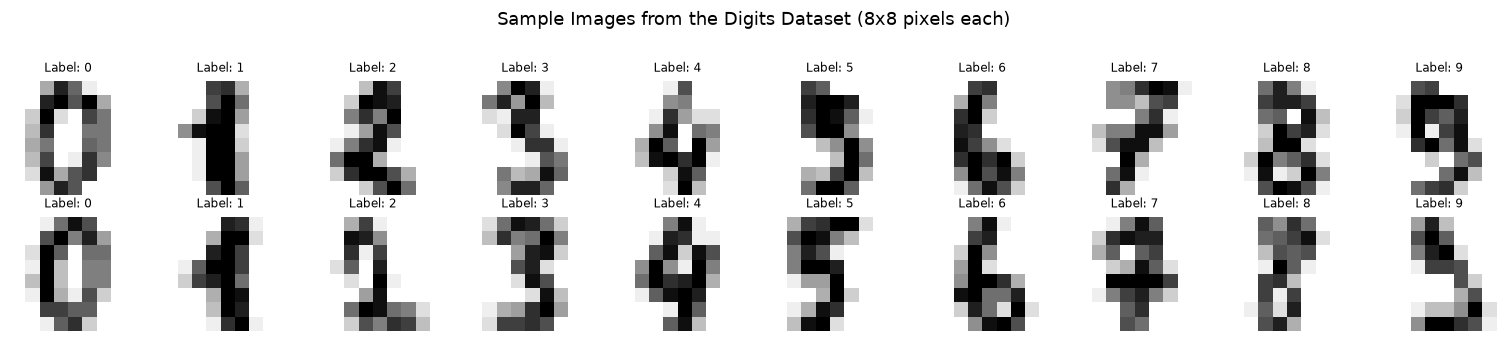

In [29]:
fig, axes = plt.subplots(2, 10, figsize=(14,3))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Label: {digits.target[i]}', fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Images from the Digits Dataset (8x8 pixels each)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

- 1 row means 1 sample of `10 digits`

---
## ⚖️ Step 2 — Scale the Data (StandardScaler)

PCA is sensitive to feature scale — a feature with larger values
dominates the covariance matrix. `StandardScaler` transforms each
feature to **mean = 0, std = 1** before PCA.

```
z = (x - mean) / std 
```

In [30]:
X = digits.data          # raw features  (1797, 64)
y = digits.target        # labels         (1797,)

scaler = StandardScaler()
X_std  = scaler.fit_transform(X)

print('Original X  shape :', X.shape)
print('Scaled X_std shape:', X_std.shape)
print(f'\nAfter scaling — Mean (should be ~0): {X_std.mean():.6f}')
print(f'After scaling — Std  (should be ~1): {X_std.std():.6f}')

Original X  shape : (1797, 64)
Scaled X_std shape: (1797, 64)

After scaling — Mean (should be ~0): 0.000000
After scaling — Std  (should be ~1): 0.976281


---
## 🧮 Step 3 — Manual Eigendecomposition (NumPy)

Before using sklearn's PCA, we manually decompose the covariance
matrix to understand what's happening under the hood.

**Recipe:**
1. Compute mean vector across all samples
2. Build the covariance matrix of the standardised data
3. Solve for eigenvalues (= variance along each PC) and eigenvectors (= PC directions)
4. Sort pairs by eigenvalue descending → PC1 = most variance
5. Compute individual and cumulative explained variance

In [31]:
# Step 3a — Covariance matrix
mean_vec = np.mean(X_std, axis=0)          # (64,)
cov_mat  = np.cov(X_std.T)                 # (64, 64)

print('Mean vector shape :', mean_vec.shape)
print('Cov matrix shape  :', cov_mat.shape)

Mean vector shape : (64,)
Cov matrix shape  : (64, 64)


In [32]:
# Step 3b — Eigendecomposition
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

print('Eigenvalues  shape :', eig_vals.shape,  ' <- one per feature (64 total)')
print('Eigenvectors shape :', eig_vecs.shape,  ' <- columns are eigenvectors')
print(f'\nTop-5 raw eigenvalues (unsorted): {eig_vals[:5].real}')

Eigenvalues  shape : (64,)  <- one per feature (64 total)
Eigenvectors shape : (64, 64)  <- columns are eigenvectors

Top-5 raw eigenvalues (unsorted): [7.34477606 5.83549054 5.15396118 3.96623597 2.9663452 ]


In [33]:
# Step 3c — Sort (eigenvalue, eigenvector) pairs descending
# Use abs() to handle tiny negative imaginary parts from floating point
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:, i]) for i in range(len(eig_vals))]
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Step 3d — Explained variance
tot      = sum(eig_vals.real)
var_exp  = [(i.real / tot) * 100 for i in sorted(eig_vals, reverse=True)]  # individual
cum_var_exp = np.cumsum(var_exp)                                             # cumulative

print('Top-10 individual explained variance (%):')
for i, v in enumerate(var_exp[:10]):
    print(f'  PC{i+1:02d}: {v:.2f}%  (cumulative: {cum_var_exp[i]:.2f}%)')

Top-10 individual explained variance (%):
  PC01: 12.03%  (cumulative: 12.03%)
  PC02: 9.56%  (cumulative: 21.59%)
  PC03: 8.44%  (cumulative: 30.04%)
  PC04: 6.50%  (cumulative: 36.54%)
  PC05: 4.86%  (cumulative: 41.40%)
  PC06: 4.21%  (cumulative: 45.61%)
  PC07: 3.94%  (cumulative: 49.55%)
  PC08: 3.39%  (cumulative: 52.94%)
  PC09: 3.00%  (cumulative: 55.94%)
  PC10: 2.93%  (cumulative: 58.87%)


---
## 📊 Step 4 — Explained Variance Plot (Scree Plot)

The scree plot shows how much variance each additional PC contributes.
The **cumulative curve** tells us how many PCs we need to retain a
target percentage of information (e.g., 95%).

> 📌 **Rule of thumb:** Choose the number of components where the
> cumulative curve starts to flatten — the *elbow point*.

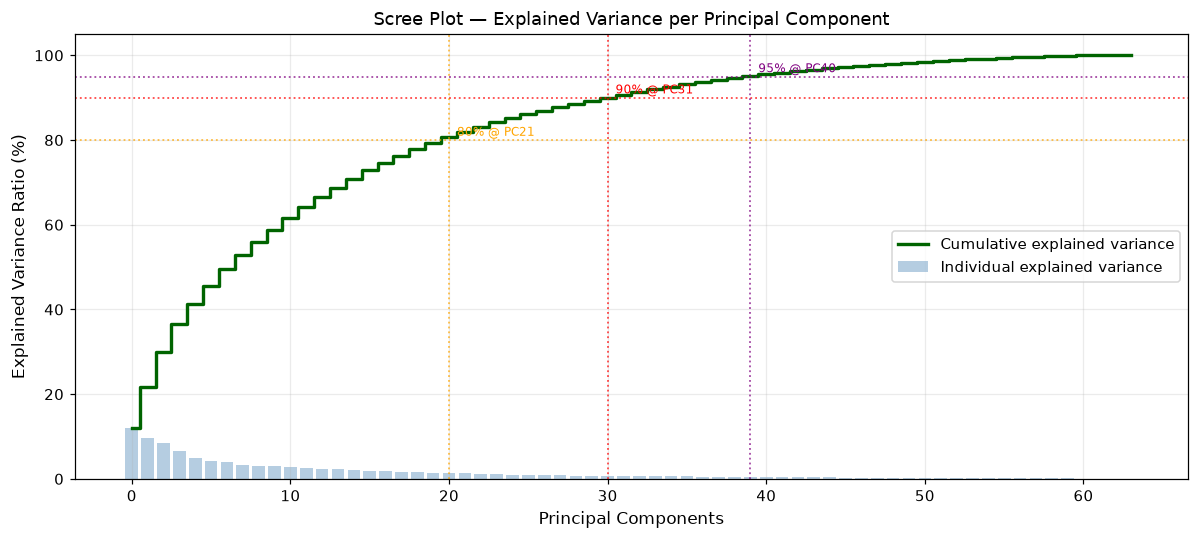

80% variance retained with 21 components
90% variance retained with 31 components
95% variance retained with 40 components


In [34]:
fig, ax = plt.subplots(figsize=(11, 5))

# Individual variance bars
ax.bar(range(len(var_exp)), var_exp,
       alpha=0.4, align='center', color='steelblue',
       label='Individual explained variance')

# Cumulative step curve
ax.step(range(len(cum_var_exp)), cum_var_exp,
        where='mid', color='darkgreen', linewidth=2.2,
        label='Cumulative explained variance')

# Reference lines
for thresh, col in [(80, 'orange'), (90, 'red'), (95, 'purple')]:
    idx = np.argmax(cum_var_exp >= thresh)
    ax.axhline(thresh, color=col, linestyle=':', linewidth=1.2, alpha=0.7)
    ax.axvline(idx,   color=col, linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(idx+0.5, thresh+1, f'{thresh}% @ PC{idx+1}', fontsize=8, color=col)

ax.set_xlabel('Principal Components', fontsize=11)
ax.set_ylabel('Explained Variance Ratio (%)', fontsize=11)
ax.set_title('Scree Plot — Explained Variance per Principal Component', fontsize=12)
ax.legend(loc='center right')
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

# Summary
for thresh in [80, 90, 95]:
    n = int(np.argmax(cum_var_exp >= thresh)) + 1
    print(f'{thresh}% variance retained with {n} components')

---
## 🔬 Step 5 — sklearn PCA with n_components = 20

From the scree plot, 20 components capture approximately **85-90%**
of the total variance — a good compression from 64 → 20 features
(68% reduction in dimensionality).

Note the standard sklearn workflow:
- Fit PCA **only on training data** (avoid data leakage)
- **Transform** both train and test using the fitted PCA

In [35]:
# Train / test split BEFORE PCA to avoid leakage
x_train, x_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=42, stratify=y)

print('x_train shape:', x_train.shape)
print('x_test  shape:', x_test.shape)

x_train shape: (1437, 64)
x_test  shape: (360, 64)


In [36]:
# Fit PCA on training data only → transform both sets
pca = PCA(n_components=20, random_state=42)
pca_x_train = pca.fit_transform(x_train)   # fit + transform on train
pca_x_test  = pca.transform(x_test)        # transform only on test

print('Before PCA — x_train shape :', x_train.shape)
print('After  PCA — pca_x_train shape:', pca_x_train.shape)
print(f'\nVariance retained with 20 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Before PCA — x_train shape : (1437, 64)
After  PCA — pca_x_train shape: (1437, 20)

Variance retained with 20 PCs: 79.97%


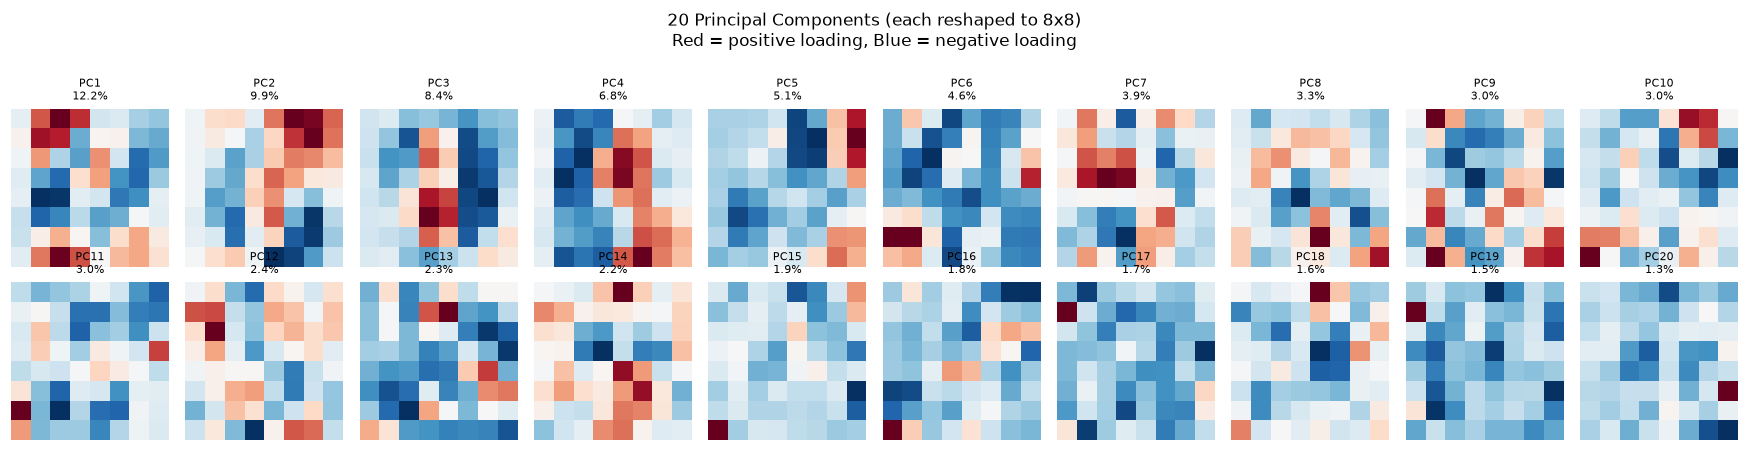

In [37]:
# Visualise the 20 principal component directions (8x8 image each)
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for i, ax in enumerate(axes.flat):
    component = pca.components_[i].reshape(8, 8)   # each component is a 64-D vector
    ax.imshow(component, cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f'PC{i+1}\n{pca.explained_variance_ratio_[i]*100:.1f}%',
                 fontsize=7)
    ax.axis('off')

plt.suptitle('20 Principal Components (each reshaped to 8x8)\n'
             'Red = positive loading, Blue = negative loading', fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

---
## 🌳 Step 6 — Decision Tree Classifier on PCA-Reduced Data

We train a Decision Tree on the 20 PCA components and compare
accuracy with and without PCA.

> 📌 The slide calls this 'PCA on Random Forest' but uses `DecisionTreeClassifier`.
> We implement exactly what the hands-on shows, then also compare with RandomForest.

In [38]:
# ── Without PCA (baseline) ─────────────────────────────────────────
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(x_train, y_train)
baseline_pred = dt_baseline.predict(x_test)
baseline_acc  = accuracy_score(y_test, baseline_pred)

# ── With PCA (20 components) ────────────────────────────────────────
dt_pca = DecisionTreeClassifier(random_state=42)
dt_pca.fit(pca_x_train, y_train)
predicted = dt_pca.predict(pca_x_test)
pca_acc   = accuracy_score(y_test, predicted)

print('='*45)
print(f'  Accuracy WITHOUT PCA (64 features): {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)')
print(f'  Accuracy WITH PCA    (20 features): {pca_acc:.4f}  ({pca_acc*100:.2f}%)')
print('='*45)
print(f'  Feature reduction: 64 → 20  ({(1-20/64)*100:.0f}% fewer features)')
print(f'  Accuracy change  : {(pca_acc - baseline_acc)*100:+.2f}%')

  Accuracy WITHOUT PCA (64 features): 0.8278  (82.78%)
  Accuracy WITH PCA    (20 features): 0.8444  (84.44%)
  Feature reduction: 64 → 20  (69% fewer features)
  Accuracy change  : +1.67%


In [39]:
# Classification report for PCA model
print('Classification Report — Decision Tree with PCA (20 components):')
print(classification_report(y_test, predicted,
                            target_names=[str(i) for i in range(10)]))

Classification Report — Decision Tree with PCA (20 components):
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        36
           1       0.84      0.89      0.86        36
           2       0.82      0.89      0.85        35
           3       0.90      0.76      0.82        37
           4       0.94      0.83      0.88        36
           5       0.80      0.89      0.85        37
           6       0.97      0.92      0.94        36
           7       0.89      0.89      0.89        36
           8       0.62      0.71      0.67        35
           9       0.78      0.78      0.78        36

    accuracy                           0.84       360
   macro avg       0.85      0.84      0.85       360
weighted avg       0.85      0.84      0.85       360

